In [1]:
import os
os.chdir('../../../..')
print(os.getcwd())
from Simulation.libraries.SimulationLib.Environment import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import csv
from ExperimentTools.utils.ExperimentLogger import EpisodeLogger, ExperimentLogger, ShortestPath
import pickle
import math

/Users/titonka/FAIRIS


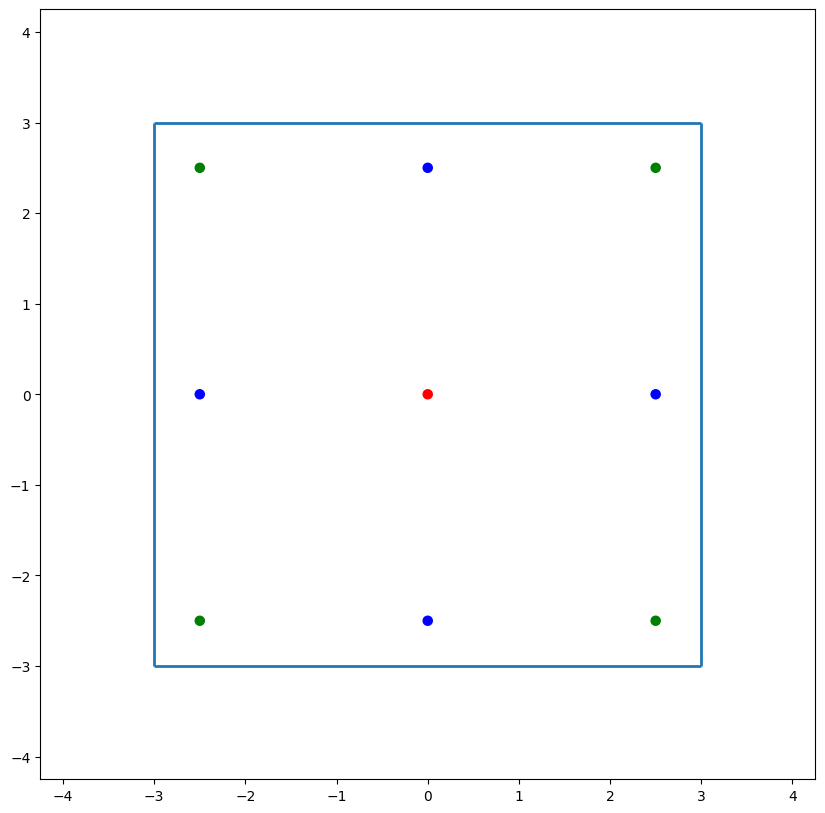

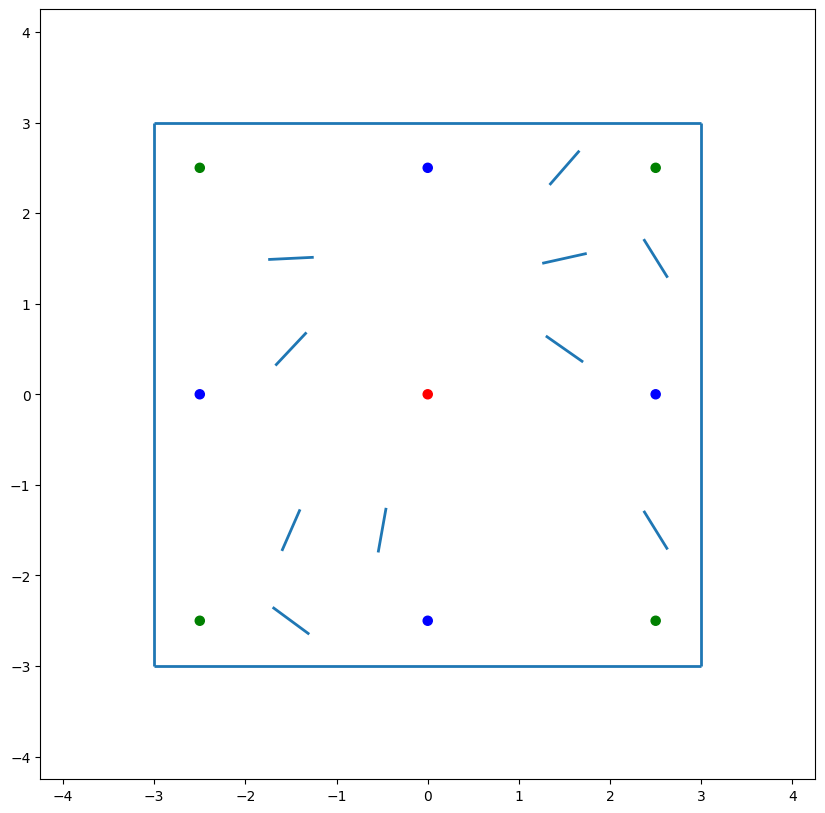

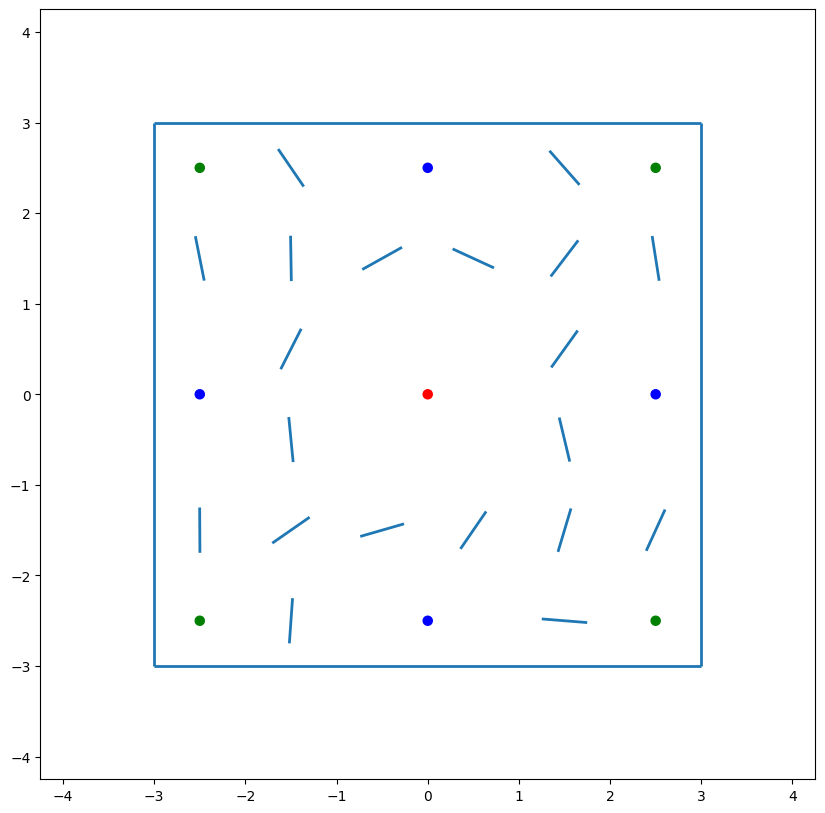

In [2]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))
def load_episodes_from_csv(filename):
    episodes = []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        current_episode = []
        
        for row in reader:
            if not row:  # Blank line signifies a new episode
                if current_episode:
                    episodes.append(current_episode)
                    current_episode = []
                continue
            
            # Convert row to a tuple of floats and add to the current episode
            current_episode.append(list(map(float, row)))
        
        if current_episode:  # Add the last episode if it exists
            episodes.append(current_episode)

    return episodes

def log_optimality_ratio(exp_data):
    maze_names = ['WM00','WM10','WM20']
    path_data = []
    name_index = 0
    for maze in mazes:
        starting_points = []
        path_lengths = []
        for path in maze.paths:
            starting_points.append(path.path[0])
            path_lengths.append(len(path.path)-1)
        path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
        name_index += 1
    
    path_metrics = {
        'WM00': path_data[0],
        'WM10': path_data[1],
        'WM20': path_data[2]
    }
    for experiment in exp_data:
        maze_ver = experiment.maze_file
        if maze_ver == 'WM00':
            data_index = 0
        elif maze_ver == 'WM10':
            data_index = 1
        shortest_path = path_metrics.get(maze_ver)
        for episode in experiment.episodes:
            start = (episode.path_xs[0] , episode.path_ys[0])
            min_dist = 100
            for s in shortest_path.starting_points:
                dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
                if dist < min_dist:
                    min_dist = dist
                    eps_start = s  
            min_length = int(shortest_path.path_lengths.get(eps_start))        
            optimality_ratio = (episode.path_length - min_length)/min_length
            experiment.log_optimality_ratio_of_paths(optimality_ratio)
            
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [5]:
experiment_data_WM00_NM = []
experiment_data_WM10_NM = []
with open('logs/LargeScale/AllPPOTrainData_WM00_uniform_25_NM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM00_NM.append(ExperimentLogger(old_data=experiment))

with open('logs/LargeScale/AllPPOTrainData_WM10_uniform_25_NM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM10_NM.append(ExperimentLogger(old_data=experiment))

log_optimality_ratio(experiment_data_WM00_NM)
log_optimality_ratio(experiment_data_WM10_NM)


experiment_data_WM00_WM = []
experiment_data_WM10_WM = []
with open('logs/LargeScale/AllPPOTrainData_WM10_uniform_25_WM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM00_WM.append(ExperimentLogger(old_data=experiment))

with open('logs/LargeScale/AllPPOTrainData_WM10_uniform_25_WM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM10_WM.append(ExperimentLogger(old_data=experiment))

log_optimality_ratio(experiment_data_WM00_WM)
log_optimality_ratio(experiment_data_WM10_WM)


experiment_data_WM00_MSRL = []
experiment_data_WM10_MSRL = []
with open('logs/LargeScale/All_MSRL_WM00_uniform_25_WM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM00_MSRL.append(ExperimentLogger(old_data=experiment))

with open('logs/LargeScale/All_MSRL_WM10_uniform_25_WM','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_WM10_MSRL.append(ExperimentLogger(old_data=experiment))

log_optimality_ratio(experiment_data_WM00_MSRL)
log_optimality_ratio(experiment_data_WM10_MSRL)

experiment_data_no_pc_MW00 = []
experiment_data_no_pc_MW10 =[]
        
with open('logs/LargeScale/AllPPOTrainData_WM00_no_pc','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_no_pc_MW00.append(ExperimentLogger(old_data=experiment))
        
with open('logs/LargeScale/AllPPOTrainData_WM10_no_pc','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        experiment_data_no_pc_MW10.append(ExperimentLogger(old_data=experiment))
        

log_optimality_ratio(experiment_data_no_pc_MW00)
log_optimality_ratio(experiment_data_no_pc_MW10)

In [6]:
def plot_boxplots_OR(experiment_data, window_size=10):
    # Ensure there are enough ExperimentLoggers
    if not experiment_data:
        raise ValueError("The list of ExperimentLoggers is empty")
    
    # Ensure all ExperimentLoggers have the same length of optimality_ratio_history
    history_lengths = [len(logger.optimality_ratio_history) for logger in experiment_data]
    if len(set(history_lengths)) != 1:
        raise ValueError("All ExperimentLoggers must have the same length of optimality_ratio_history")
    num_elements = history_lengths[0]
    num_windows = num_elements // window_size
    
    # Create a list of lists for boxplots
    boxplot_data = [[] for _ in range(num_windows)]
    x_ticks = []
    
    for logger in experiment_data:
        for i in range(num_windows):
            start = i * window_size
            end = start + window_size
            window_avg = np.mean(logger.optimality_ratio_history[start:end])
            boxplot_data[i].append(window_avg)
    
    # Calculate medians and STD for each window
    medians = [np.median(window_data) for window_data in boxplot_data]
    means = [np.mean(window_data) for window_data in boxplot_data]
    stds = [np.std(window_data) for window_data in boxplot_data]
    q1 = [np.percentile(window_data, 25) for window_data in boxplot_data]
    q3 = [np.percentile(window_data, 75) for window_data in boxplot_data]
    
    # Generate x-tick labels corresponding to the original episode indices
    x_ticks = [i * window_size for i in range(num_windows)]
    
    # Plot the boxplots and median line
    plt.figure(figsize=(12, 6))
    
    # Plot shaded STD area
    plt.fill_between(x_ticks, np.array(means) - np.array(stds), np.array(means) + np.array(stds), color='lightgray', alpha=0.5, label='STD')
    # plt.fill_between(range(num_windows), q1, q3, color='blue', alpha=0.5, label='IQR')
    
    # Plot median line
    plt.plot(x_ticks, means, color='blue', label='Median')
    
    # Add additional formatting and labels
    plt.xlabel('Episode Index')
    plt.ylabel('Average Optimality Ratio')
    plt.title(f'Median and STD of {window_size}-Episode Averages Across ExperimentLoggers')
    plt.legend()
    plt.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    plt.show()

In [7]:
def plot_LT_OR_Multi(experiment_data_no_pc, experiment_data_nm, experiment_data_wm, experiment_data_MSRL, window_size=10, shade="std"):
    def process_experiment_data(experiment_data, window_size):
        # Ensure there are enough ExperimentLoggers
        if not experiment_data:
            raise ValueError("The list of ExperimentLoggers is empty")
        
        # Ensure all ExperimentLoggers have the same length of optimality_ratio_history
        history_lengths = [len(logger.optimality_ratio_history) for logger in experiment_data]
        if len(set(history_lengths)) != 1:
            raise ValueError("All ExperimentLoggers must have the same length of optimality_ratio_history")
        num_elements = history_lengths[0]
        num_windows = num_elements // window_size
        
        # Create a list of lists for boxplots
        boxplot_data = [[] for _ in range(num_windows)]
        
        for logger in experiment_data:
            for i in range(num_windows):
                start = i * window_size
                end = start + window_size
                window_avg = np.mean(logger.optimality_ratio_history[start:end])
                boxplot_data[i].append(window_avg)
        
        # Calculate medians and STD for each window
        medians = [np.median(window_data) for window_data in boxplot_data]
        means = [np.mean(window_data) for window_data in boxplot_data]
        stds = [np.std(window_data) for window_data in boxplot_data]
        q1 = [np.percentile(window_data, 25) for window_data in boxplot_data]
        q3 = [np.percentile(window_data, 75) for window_data in boxplot_data]
        
        return means, stds, medians, q1, q3
    
    means_no_pc, stds_no_pc, meds_no_pc, q1_no_pc, q3_no_pc = process_experiment_data(experiment_data_no_pc, window_size)
    means_nm, stds_nm, meds_nm, q1_nm, q3_nm = process_experiment_data(experiment_data_nm, window_size)
    means_wm, stds_wm, meds_wm, q1_wm, q3_wm = process_experiment_data(experiment_data_wm, window_size)
    means_MSRL, stds_MSRL, meds_MSRL, q1_MSRL, q3_MSRL = process_experiment_data(experiment_data_MSRL, window_size)
    
    # Generate x-tick labels corresponding to the original episode indices
    num_windows = len(means_no_pc)
    x_ticks = [i * window_size for i in range(num_windows)]
    
    # Plot the boxplots and median line
    plt.figure(figsize=(12, 6))
    
    if shade == 'std':
        # Plot shaded STD area for no_pc
        plt.fill_between(x_ticks, np.array(means_no_pc) - np.array(stds_no_pc), np.array(means_no_pc) + np.array(stds_no_pc), color='lightgray', alpha=0.5, label='STD No PC')
        plt.plot(x_ticks, means_no_pc, color='blue', label='Median No PC')
        
        # Plot shaded STD area for nm
        plt.fill_between(x_ticks, np.array(means_nm) - np.array(stds_nm), np.array(means_nm) + np.array(stds_nm), color='lightcoral', alpha=0.5, label='STD NM')
        plt.plot(x_ticks, means_nm, color='red', label='Median NM')
        
        # Plot shaded STD area for wm
        plt.fill_between(x_ticks, np.array(means_wm) - np.array(stds_wm), np.array(means_wm) + np.array(stds_wm), color='lightgreen', alpha=0.5, label='STD WM')
        plt.plot(x_ticks, means_wm, color='green', label='Median WM')

        # Plot shaded STD area for new
        plt.fill_between(x_ticks, np.array(means_MSRL) - np.array(stds_MSRL), np.array(means_MSRL) + np.array(stds_MSRL), color='lightblue', alpha=0.5, label='STD SMRL')
        plt.plot(x_ticks, means_MSRL, color='purple', label='Median MSRL')
    else:
        # Plot IQR area for no_pc
        plt.fill_between(x_ticks, q1_no_pc, q3_no_pc, color='lightgray', alpha=0.5, label='IQR No PC')
        plt.plot(x_ticks, meds_no_pc, color='blue', label='Median No PC')
        
        # Plot IQR area for nm
        plt.fill_between(x_ticks, q1_nm, q3_nm, color='lightcoral', alpha=0.5, label='IQR NM')
        plt.plot(x_ticks, meds_nm, color='red', label='Median NM')
        
        # Plot IQR area for wm
        plt.fill_between(x_ticks, q1_wm, q3_wm, color='lightgreen', alpha=0.5, label='IQR WM')
        plt.plot(x_ticks, meds_wm, color='green', label='Median WM')

        # Plot IQR area for new
        plt.fill_between(x_ticks, q1_MSRL, q3_MSRL, color='lightblue', alpha=0.5, label='IQR MSRL')
        plt.plot(x_ticks, meds_MSRL, color='purple', label='Median MSRL')
    
    # Add additional formatting and labels
    plt.xlabel('Episode Index')
    plt.ylabel('Average Optimality Ratio')
    plt.title(f'Median and IQR of {window_size}-Episode Averages Across ExperimentLoggers')
    plt.legend()
    plt.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    plt.show()



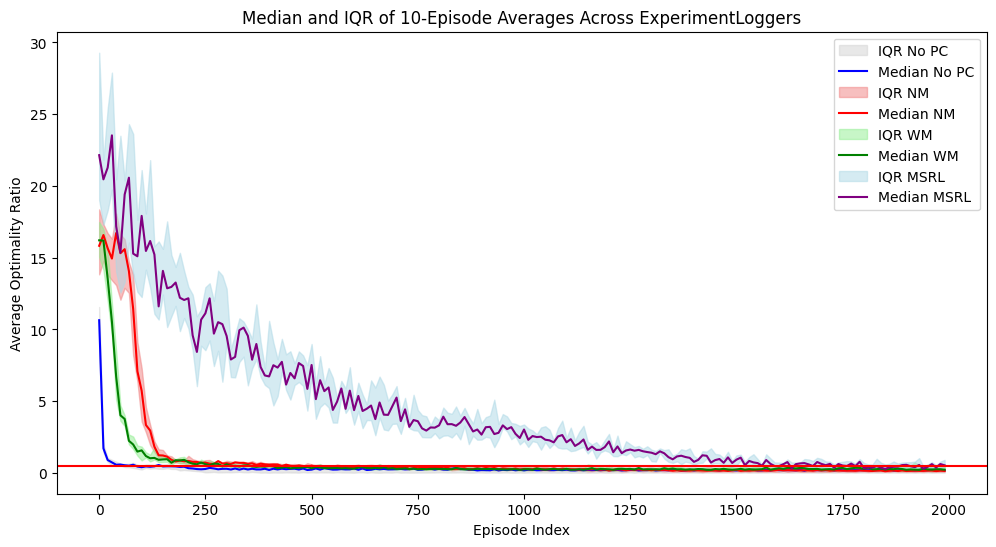

In [9]:
plot_LT_OR_Multi(experiment_data_no_pc_MW00,experiment_data_WM00_NM,experiment_data_WM00_WM,experiment_data_WM00_MSRL,shade='iqr')

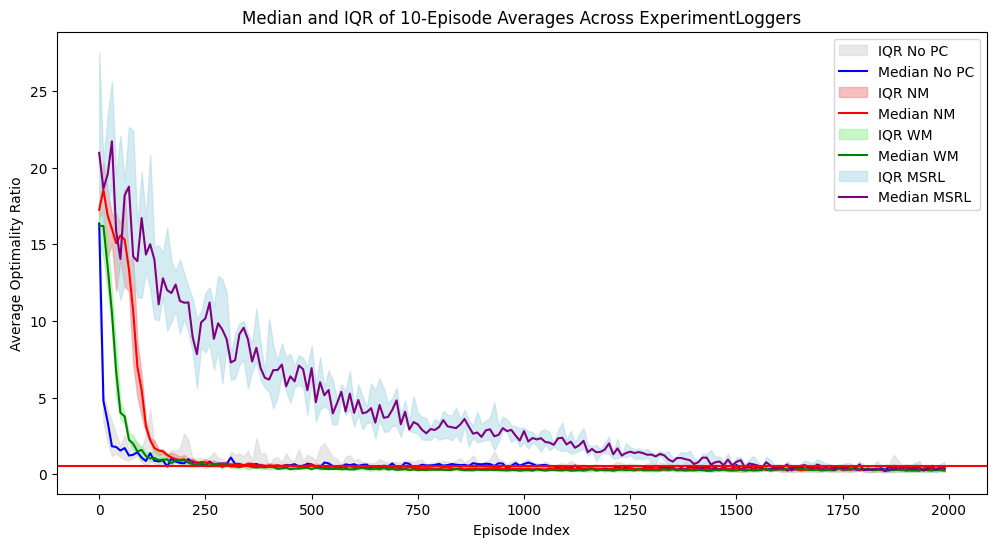

In [8]:
plot_LT_OR_Multi(experiment_data_no_pc_MW10,experiment_data_WM10_NM,experiment_data_WM10_WM,experiment_data_WM10_MSRL,shade='iqr')

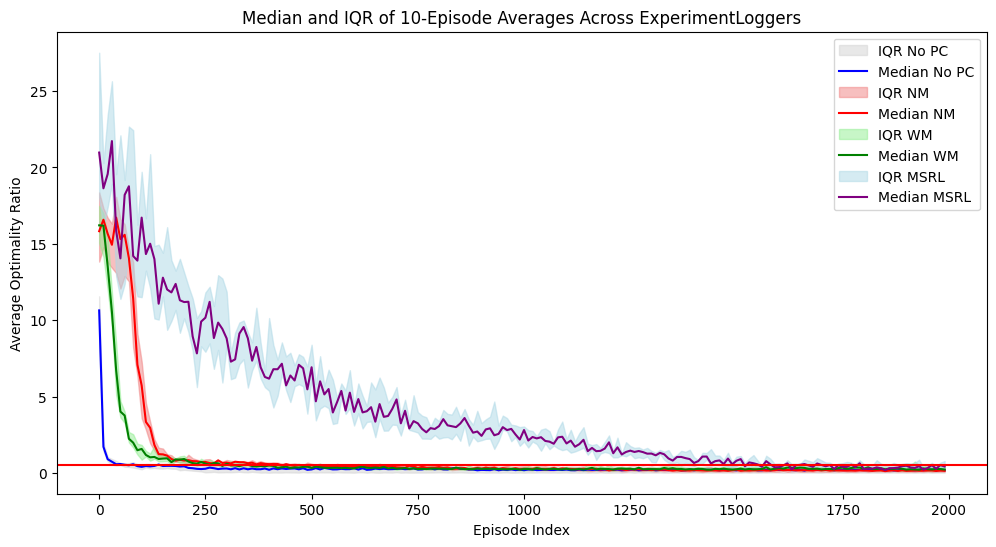

In [10]:
plot_LT_OR_Multi(experiment_data_no_pc_MW00,experiment_data_WM00_NM,experiment_data_WM00_WM,experiment_data_WM10_MSRL,shade='iqr')

In [11]:
def test_optimality_ratio_significance(experiment_data_no_pc, experiment_data_nm, experiment_data_wm, experiment_data_msrl, window_size=20, threshold=0.5):
    def time_to_reach_threshold(experiment_data, window_size, threshold):
        times = []
        for logger in experiment_data:
            moving_averages = np.convolve(logger.optimality_ratio_history, np.ones(window_size)/window_size, mode='valid')
            for i, avg in enumerate(moving_averages):
                if avg <= threshold:
                    times.append(i + window_size - 1)  # Adjust for the window size
                    break
            else:
                # If the threshold is never reached, append a large number
                times.append(len(logger.optimality_ratio_history))
        return times
    
    times_no_pc = time_to_reach_threshold(experiment_data_no_pc, window_size, threshold)
    times_nm = time_to_reach_threshold(experiment_data_nm, window_size, threshold)
    times_wm = time_to_reach_threshold(experiment_data_wm, window_size, threshold)
    times_msrl = time_to_reach_threshold(experiment_data_msrl, window_size, threshold)
    
    # Perform pairwise Mann-Whitney U tests
    u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc = stats.mannwhitneyu(times_nm, times_no_pc, alternative='two-sided')
    u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc = stats.mannwhitneyu(times_wm, times_no_pc, alternative='two-sided')
    u_statistic_wm_vs_nm, p_value_wm_vs_nm = stats.mannwhitneyu(times_wm, times_nm, alternative='two-sided')
    u_statistic_nm_vs_msrl, p_value_nm_vs_msrl = stats.mannwhitneyu(times_nm, times_msrl, alternative='two-sided')
    u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = stats.mannwhitneyu(times_wm, times_msrl, alternative='two-sided')
   
    
    # Print results
    print(f"Times with Place Cells (WM): {times_wm}")
    print(f"Times with Place Cells (NM): {times_nm}")
    print(f"Times without Place Cells: {times_no_pc}")
    print(f"Times with MSRL: {times_msrl}")
    
    print(f"U Statistic (NM vs. No PC): {u_statistic_nm_vs_no_pc}")
    print(f"P-value (NM vs. No PC): {p_value_nm_vs_no_pc}")
    
    print(f"U Statistic (WM vs. No PC): {u_statistic_wm_vs_no_pc}")
    print(f"P-value (WM vs. No PC): {p_value_wm_vs_no_pc}")
    
    print(f"U Statistic (WM vs. NM): {u_statistic_wm_vs_nm}")
    print(f"P-value (WM vs. NM): {p_value_wm_vs_nm}")
    
    print(f"U Statistic (NM vs. MSRL): {u_statistic_nm_vs_msrl}")
    print(f"P-value (NM vs. MSRL): {p_value_nm_vs_msrl}")
    
    print(f"U Statistic (WM vs. MSRL): {u_statistic_wm_vs_msrl}")
    print(f"P-value (WM vs. No MSRL): {p_value_wm_vs_msrl}")
    
    # Interpret the p-values
    def interpret_p_value(p_value):
        if p_value < 0.05:
            return "The difference is statistically significant."
        else:
            return "The difference is not statistically significant."
    
    print("NM vs. No PC:", interpret_p_value(p_value_nm_vs_no_pc))
    print("WM vs. No PC:", interpret_p_value(p_value_wm_vs_no_pc))
    print("WM vs. NM:", interpret_p_value(p_value_wm_vs_nm))
    print("NM vs. MSRL:", interpret_p_value(p_value_nm_vs_msrl))
    print("WM vs. MSRL:", interpret_p_value(p_value_wm_vs_msrl))
    
    return times_no_pc, times_nm, times_wm, times_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm, u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Maze: WM00
Times with Place Cells (WM): [2000, 270, 492, 300, 301, 389, 201, 180, 359, 161]
Times with Place Cells (NM): [394, 226, 545, 437, 477, 489, 397, 276, 266, 1026]
Times without Place Cells: [2000, 52, 74, 113, 69, 60, 48, 120, 41, 80]
Times with MSRL: [1464, 1409, 1234, 1533, 1379, 1512, 1570, 1647, 1487, 1310]
U Statistic (NM vs. No PC): 90.0
P-value (NM vs. No PC): 0.0028272720911168077
U Statistic (WM vs. No PC): 90.5
P-value (WM vs. No PC): 0.002487538658093602
U Statistic (WM vs. NM): 32.0
P-value (WM vs. NM): 0.18587673236587576
U Statistic (NM vs. MSRL): 0.0
P-value (NM vs. MSRL): 0.00018267179110955002
U Statistic (WM vs. MSRL): 10.0
P-value (WM vs. No MSRL): 0.0028272720911168077
NM vs. No PC: The difference is statistically significant.
WM vs. No PC: The difference is statistically significant.
WM vs. NM: The difference is not statistically significant.
NM vs. MSRL: The difference is statistically significant.
WM vs. MSRL: The difference is statistically significant

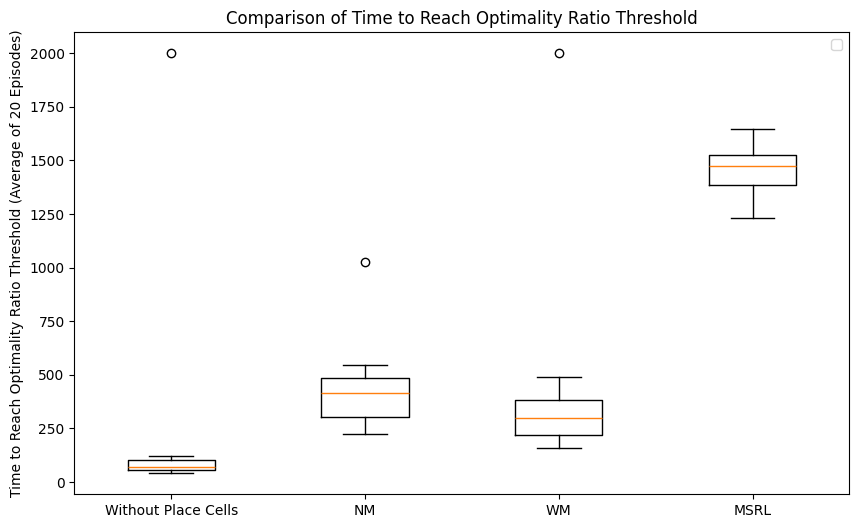

In [21]:
print("Maze: WM00")
times_no_pc, times_nm, times_wm, times_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm,  u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = test_optimality_ratio_significance(experiment_data_no_pc_MW00, experiment_data_WM00_NM, experiment_data_WM00_WM,experiment_data_WM00_MSRL)

plt.figure(figsize=(10, 6))
plt.boxplot([times_no_pc, times_nm, times_wm,times_msrl], labels=['Without Place Cells', 'NM', 'WM','MSRL'])
plt.ylabel('Time to Reach Optimality Ratio Threshold (Average of 20 Episodes)')
plt.title('Comparison of Time to Reach Optimality Ratio Threshold')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Maze: WM10
Times with Place Cells (WM): [2000, 270, 492, 300, 301, 389, 201, 180, 359, 161]
Times with Place Cells (NM): [625, 290, 296, 372, 272, 308, 961, 624, 448, 377]
Times without Place Cells: [131, 162, 263, 116, 227, 1012, 121, 464, 213, 1600]
Times with MSRL: [1454, 1328, 1233, 1530, 1376, 1418, 1382, 1569, 1482, 1305]
U Statistic (NM vs. No PC): 73.0
P-value (NM vs. No PC): 0.08897301170181328
U Statistic (WM vs. No PC): 64.0
P-value (WM vs. No PC): 0.3074894566186813
U Statistic (WM vs. NM): 33.0
P-value (WM vs. NM): 0.21229383619233155
U Statistic (NM vs. MSRL): 0.0
P-value (NM vs. MSRL): 0.00018267179110955002
U Statistic (WM vs. MSRL): 10.0
P-value (WM vs. No MSRL): 0.0028272720911168077
NM vs. No PC: The difference is not statistically significant.
WM vs. No PC: The difference is not statistically significant.
WM vs. NM: The difference is not statistically significant.
NM vs. MSRL: The difference is statistically significant.
WM vs. MSRL: The difference is statistically 

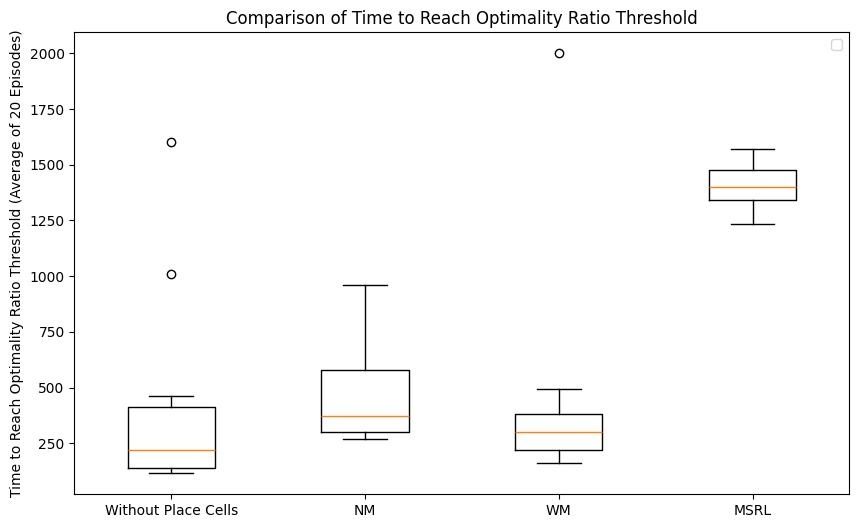

In [22]:
print("Maze: WM10")
times_no_pc, times_nm, times_wm, times_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm,  u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = test_optimality_ratio_significance(experiment_data_no_pc_MW10, experiment_data_WM10_NM, experiment_data_WM10_WM,experiment_data_WM10_MSRL)

plt.figure(figsize=(10, 6))
plt.boxplot([times_no_pc, times_nm, times_wm,times_msrl], labels=['Without Place Cells', 'NM', 'WM','MSRL'])
plt.ylabel('Time to Reach Optimality Ratio Threshold (Average of 20 Episodes)')
plt.title('Comparison of Time to Reach Optimality Ratio Threshold')
plt.legend()
plt.show()

In [13]:
def test_last_20_episodes_significance(experiment_data_no_pc, experiment_data_nm, experiment_data_wm, experiment_data_msrl):
    def last_20_optimality_ratios(experiment_data):
        last_20_ratios = []
        for logger in experiment_data:
            last_20_ratios.append(np.mean(logger.optimality_ratio_history[-20:]))
        return last_20_ratios
    
    last_20_ratios_no_pc = last_20_optimality_ratios(experiment_data_no_pc)
    last_20_ratios_nm = last_20_optimality_ratios(experiment_data_nm)
    last_20_ratios_wm = last_20_optimality_ratios(experiment_data_wm)
    last_20_ratios_msrl = last_20_optimality_ratios(experiment_data_msrl)
    
    # Perform pairwise Mann-Whitney U tests
    u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc = stats.mannwhitneyu(last_20_ratios_nm, last_20_ratios_no_pc, alternative='two-sided')
    u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc = stats.mannwhitneyu(last_20_ratios_wm, last_20_ratios_no_pc, alternative='two-sided')
    u_statistic_wm_vs_nm, p_value_wm_vs_nm = stats.mannwhitneyu(last_20_ratios_wm, last_20_ratios_nm, alternative='two-sided')
    u_statistic_nm_vs_msrl, p_value_nm_vs_msrl = stats.mannwhitneyu(last_20_ratios_nm, last_20_ratios_msrl, alternative='two-sided')
    u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = stats.mannwhitneyu(last_20_ratios_wm, last_20_ratios_msrl, alternative='two-sided')
    
    
    # Print results
    print(f"Last 20 Optimality Ratios with Place Cells (WM): {last_20_ratios_wm}")
    print(f"Last 20 Optimality Ratios with Place Cells (NM): {last_20_ratios_nm}")
    print(f"Last 20 Optimality Ratios without Place Cells: {last_20_ratios_no_pc}")
    print(f"Last 20 Optimality Ratios with MSRL: {last_20_ratios_msrl}")
    
    print(f"U Statistic (NM vs. No PC): {u_statistic_nm_vs_no_pc}")
    print(f"P-value (NM vs. No PC): {p_value_nm_vs_no_pc}")
    
    print(f"U Statistic (WM vs. No PC): {u_statistic_wm_vs_no_pc}")
    print(f"P-value (WM vs. No PC): {p_value_wm_vs_no_pc}")
    
    print(f"U Statistic (WM vs. NM): {u_statistic_wm_vs_nm}")
    print(f"P-value (WM vs. NM): {p_value_wm_vs_nm}")
    
    print(f"U Statistic (NM vs. MSRL): {u_statistic_nm_vs_msrl}")
    print(f"P-value (NM vs. MSRL): {p_value_nm_vs_msrl}")
    
    print(f"U Statistic (WM vs. MSRL): {u_statistic_wm_vs_msrl}")
    print(f"P-value (WM vs. No MSRL): {p_value_wm_vs_msrl}")
    
    
    # Interpret the p-values
    def interpret_p_value(p_value):
        if p_value < 0.05:
            return "The difference is statistically significant."
        else:
            return "The difference is not statistically significant."
    
    print("NM vs. No PC:", interpret_p_value(p_value_nm_vs_no_pc))
    print("WM vs. No PC:", interpret_p_value(p_value_wm_vs_no_pc))
    print("WM vs. NM:", interpret_p_value(p_value_wm_vs_nm))
    print("NM vs. MSRL:", interpret_p_value(p_value_nm_vs_msrl))
    print("WM vs. MSRL:", interpret_p_value(p_value_wm_vs_msrl))
 
    
    return last_20_ratios_no_pc, last_20_ratios_nm, last_20_ratios_wm, last_20_ratios_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm, u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl

Maze: WM00
Last 20 Optimality Ratios with Place Cells (WM): [0.5818181818181818, 0.19136363636363635, 0.5772727272727274, 0.12272727272727271, 0.2909090909090909, 0.2545454545454545, 1.955, 0.14999999999999997, 0.24636363636363634, 0.20727272727272728]
Last 20 Optimality Ratios with Place Cells (NM): [0.36500000000000005, 0.0, 0.325, 0.09, 0.09, 0.215, 0.11000000000000001, 0.10500000000000001, 0.29500000000000004, 0.18]
Last 20 Optimality Ratios without Place Cells: [0.6500000000000001, 0.005, 0.32999999999999996, 0.53, 0.0, 0.44000000000000006, 0.21000000000000002, 0.0, 0.1, 0.2]
Last 20 Optimality Ratios with MSRL: [0.43999999999999995, 0.5599999999999999, 0.4149999999999999, 0.76, 0.8950000000000001, 0.6399999999999999, 0.5499999999999999, 0.9700000000000001, 0.71, 0.5199999999999999]
U Statistic (NM vs. No PC): 44.0
P-value (NM vs. No PC): 0.6770115120224494
U Statistic (WM vs. No PC): 63.0
P-value (WM vs. No PC): 0.344522779098129
U Statistic (WM vs. NM): 73.0
P-value (WM vs. NM):

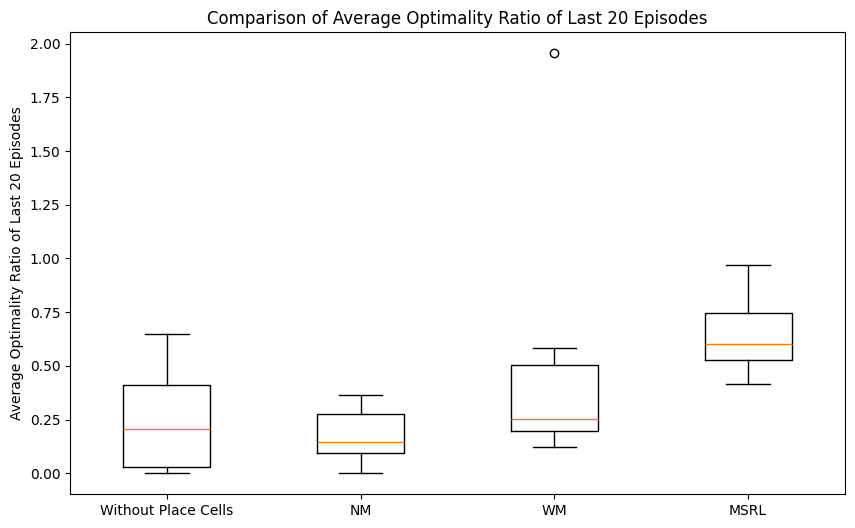

In [17]:
print('Maze: WM00')
last_20_ratios_no_pc, last_20_ratios_nm, last_20_ratios_wm, last_20_ratios_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm, u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = test_last_20_episodes_significance(experiment_data_no_pc_MW00, experiment_data_WM00_NM, experiment_data_WM00_WM,experiment_data_WM00_MSRL)

# Optional: Plotting the last 20 episode optimality ratios to visualize
plt.figure(figsize=(10, 6))
plt.boxplot([last_20_ratios_no_pc, last_20_ratios_nm, last_20_ratios_wm,last_20_ratios_msrl], labels=['Without Place Cells', 'NM', 'WM','MSRL'])
plt.ylabel('Average Optimality Ratio of Last 20 Episodes')
plt.title('Comparison of Average Optimality Ratio of Last 20 Episodes')
plt.show()

Maze: WM10
Last 20 Optimality Ratios with Place Cells (WM): [0.5818181818181818, 0.19136363636363635, 0.5772727272727274, 0.12272727272727271, 0.2909090909090909, 0.2545454545454545, 1.955, 0.14999999999999997, 0.24636363636363634, 0.20727272727272728]
Last 20 Optimality Ratios with Place Cells (NM): [0.46818181818181814, 0.15454545454545454, 0.1181818181818182, 0.12272727272727273, 0.28181818181818186, 0.3231818181818182, 0.5863636363636363, 0.42318181818181816, 0.4454545454545455, 0.2913636363636364]
Last 20 Optimality Ratios without Place Cells: [0.14545454545454542, 0.4045454545454546, 0.5181818181818183, 0.24545454545454543, 0.55, 0.23181818181818178, 0.3454545454545455, 0.5454545454545456, 0.2, 0.5577272727272728]
Last 20 Optimality Ratios with MSRL: [0.34045454545454545, 0.4504545454545454, 0.315, 0.625, 0.7963636363636364, 0.53, 0.4468181818181818, 0.8168181818181818, 0.6309090909090909, 0.40681818181818175]
U Statistic (NM vs. No PC): 41.0
P-value (NM vs. No PC): 0.52052288327

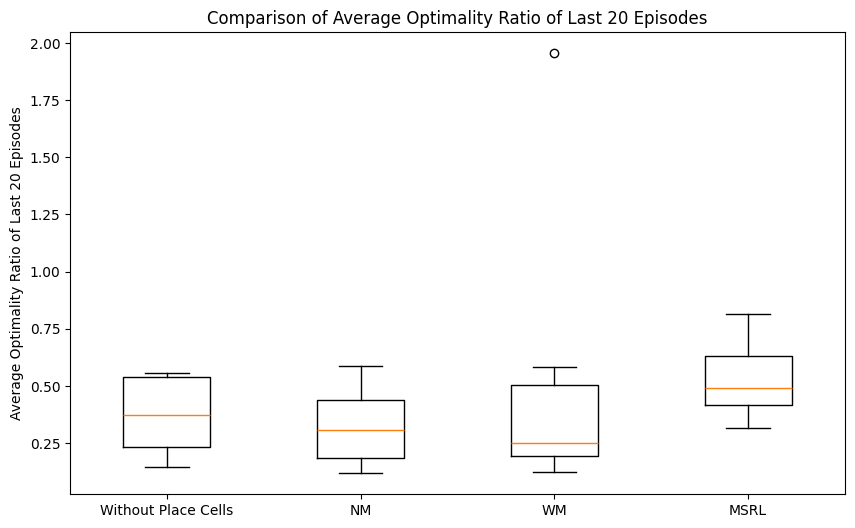

In [18]:
print('Maze: WM10')
last_20_ratios_no_pc, last_20_ratios_nm, last_20_ratios_wm, last_20_ratios_msrl, u_statistic_nm_vs_no_pc, p_value_nm_vs_no_pc, u_statistic_wm_vs_no_pc, p_value_wm_vs_no_pc, u_statistic_wm_vs_nm, p_value_wm_vs_nm, u_statistic_nm_vs_msrl, p_value_nm_vs_msrl, u_statistic_wm_vs_msrl, p_value_wm_vs_msrl = test_last_20_episodes_significance(experiment_data_no_pc_MW10, experiment_data_WM10_NM, experiment_data_WM10_WM,experiment_data_WM10_MSRL)

# Optional: Plotting the last 20 episode optimality ratios to visualize
plt.figure(figsize=(10, 6))
plt.boxplot([last_20_ratios_no_pc, last_20_ratios_nm, last_20_ratios_wm,last_20_ratios_msrl], labels=['Without Place Cells', 'NM', 'WM','MSRL'])
plt.ylabel('Average Optimality Ratio of Last 20 Episodes')
plt.title('Comparison of Average Optimality Ratio of Last 20 Episodes')
plt.show()

In [15]:
def plot_optimality_ratios_avg(experiment_data, window_size=20, title='Optimality Ratios for Each Model', xlabel='Episodes', ylabel='Optimality Ratio'):
    plt.figure(figsize=(12, 6))
    
    for i, logger in enumerate(experiment_data):
        optimality_ratios = logger.optimality_ratio_history
        avg_optimality_ratios = [np.mean(optimality_ratios[j:j+window_size]) for j in range(0, len(optimality_ratios), window_size)]
        avg_optimality_ratios_extended = np.repeat(avg_optimality_ratios, window_size)[:len(optimality_ratios)]
        
        plt.plot(avg_optimality_ratios, label=f'Model {i+1}')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc='best')
    plt.axhline(y=0.5, color='r', linestyle='--', label='Optimality Threshold')
    plt.legend()
    plt.show()

Maze: WM00


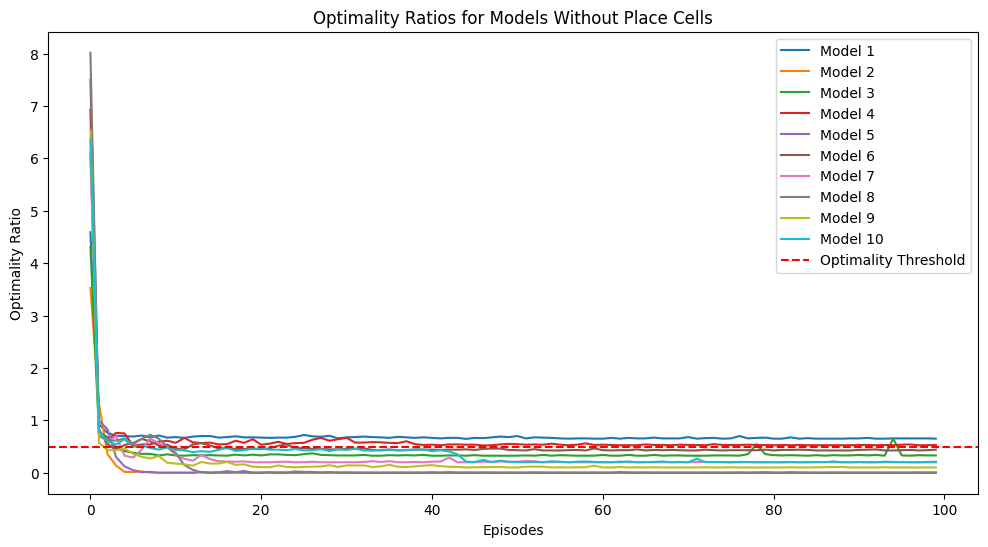

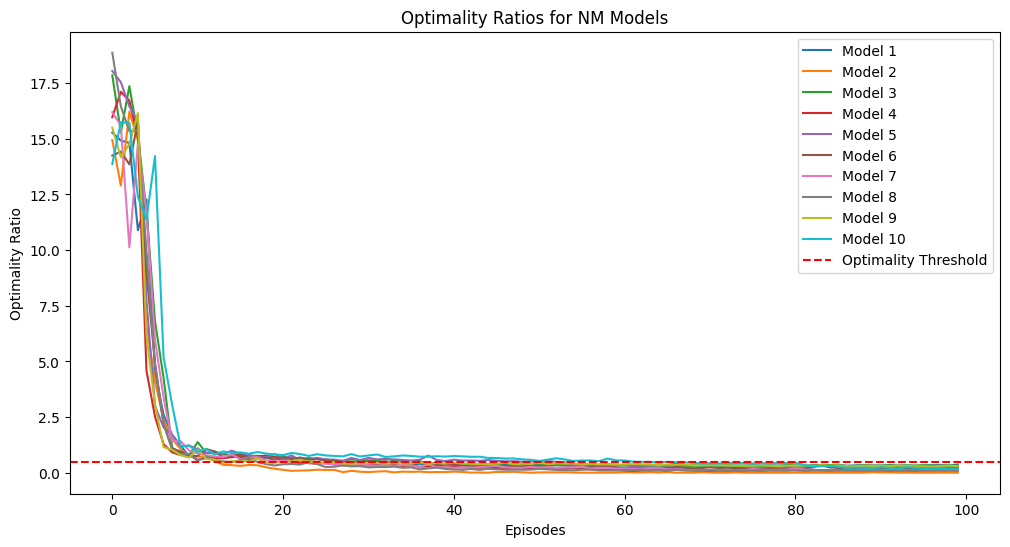

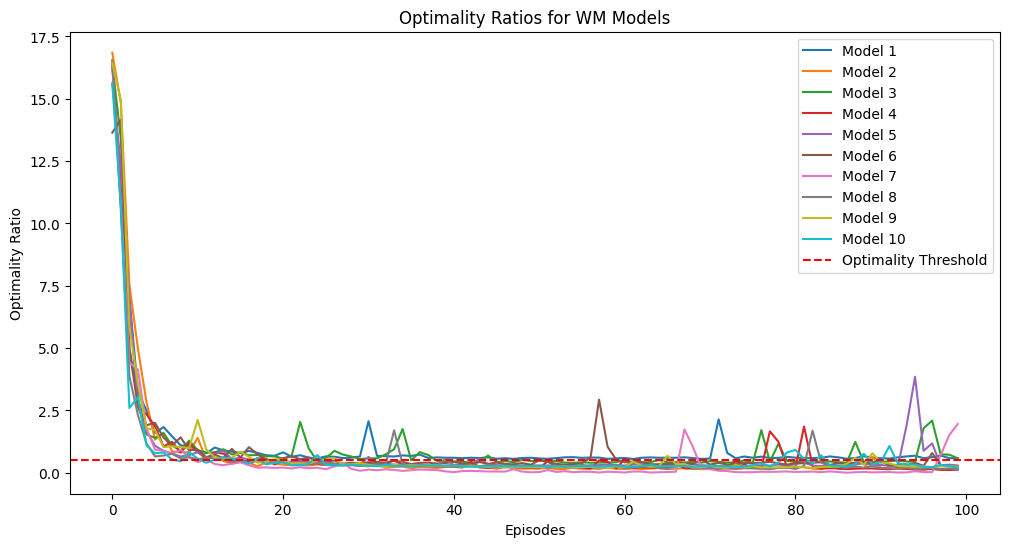

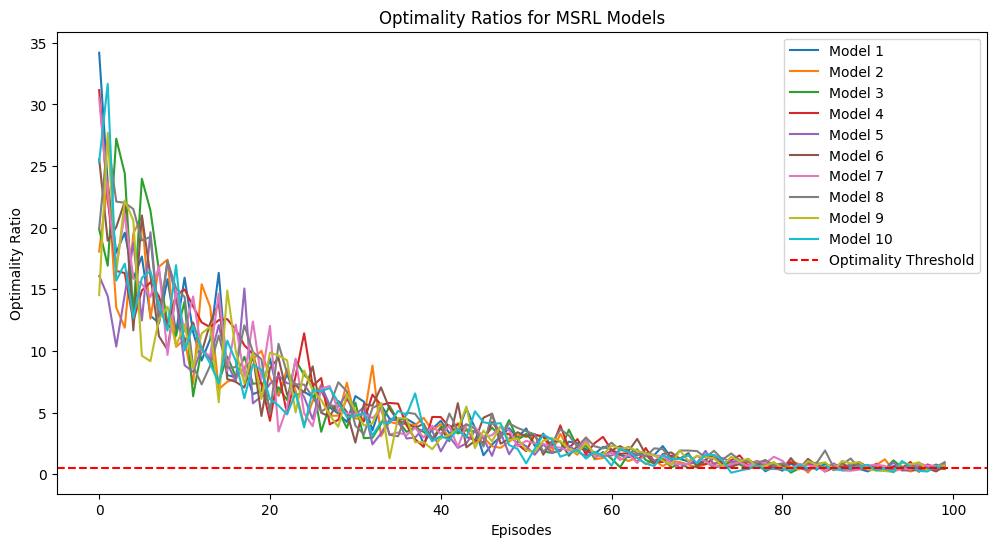

In [19]:
print('Maze: WM00')
plot_optimality_ratios_avg(experiment_data_no_pc_MW00, title='Optimality Ratios for Models Without Place Cells')
plot_optimality_ratios_avg(experiment_data_WM00_NM, title='Optimality Ratios for NM Models')
plot_optimality_ratios_avg(experiment_data_WM00_WM, title='Optimality Ratios for WM Models')
plot_optimality_ratios_avg(experiment_data_WM00_MSRL, title='Optimality Ratios for MSRL Models')

Maze: WM10


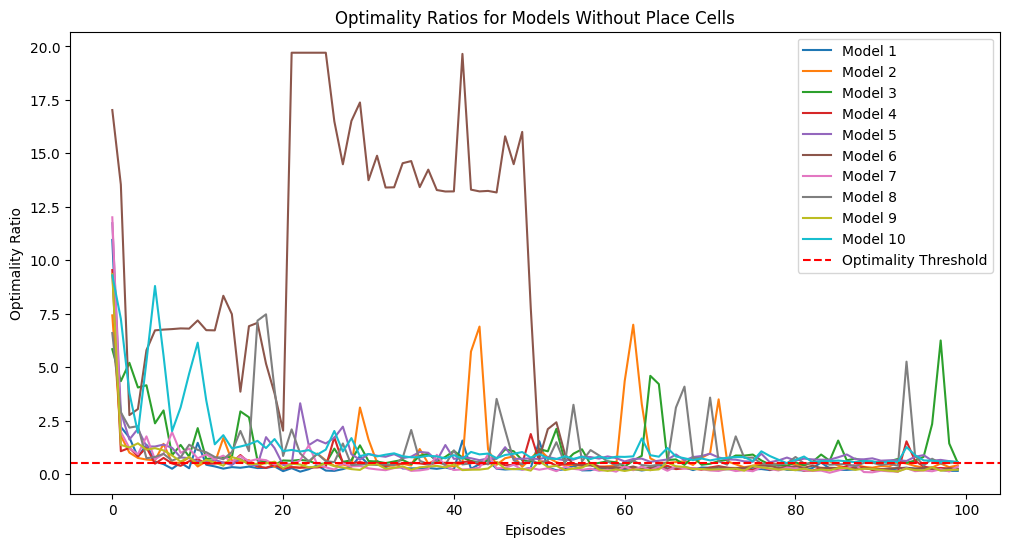

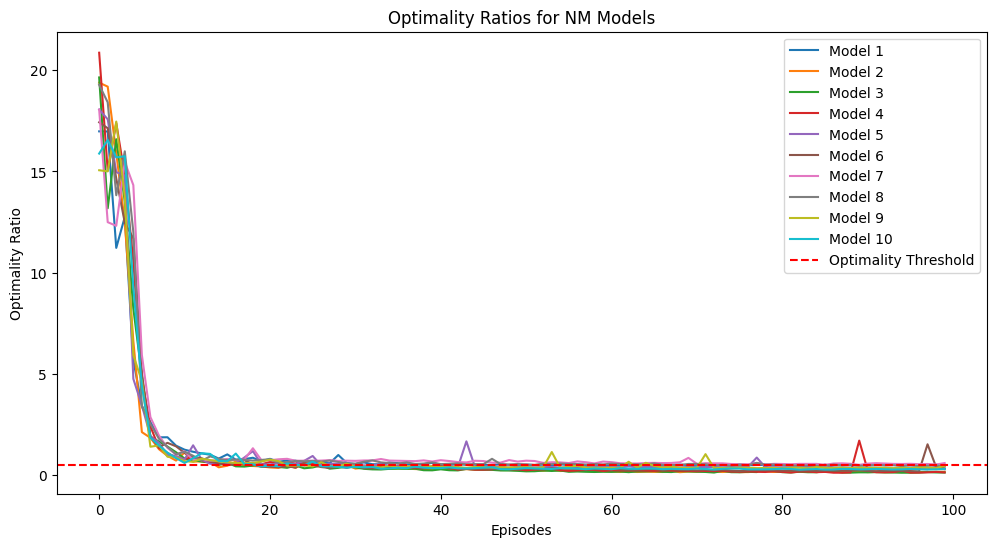

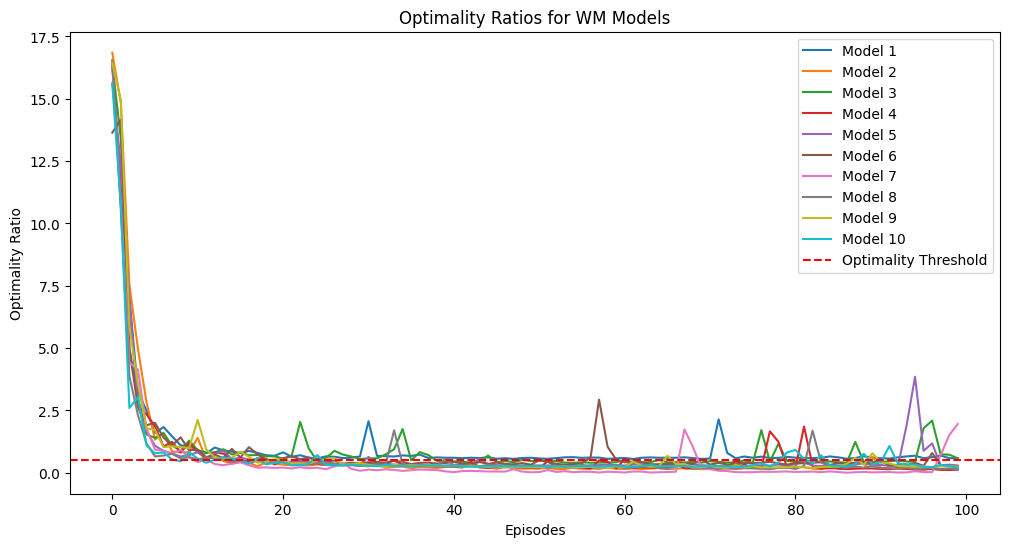

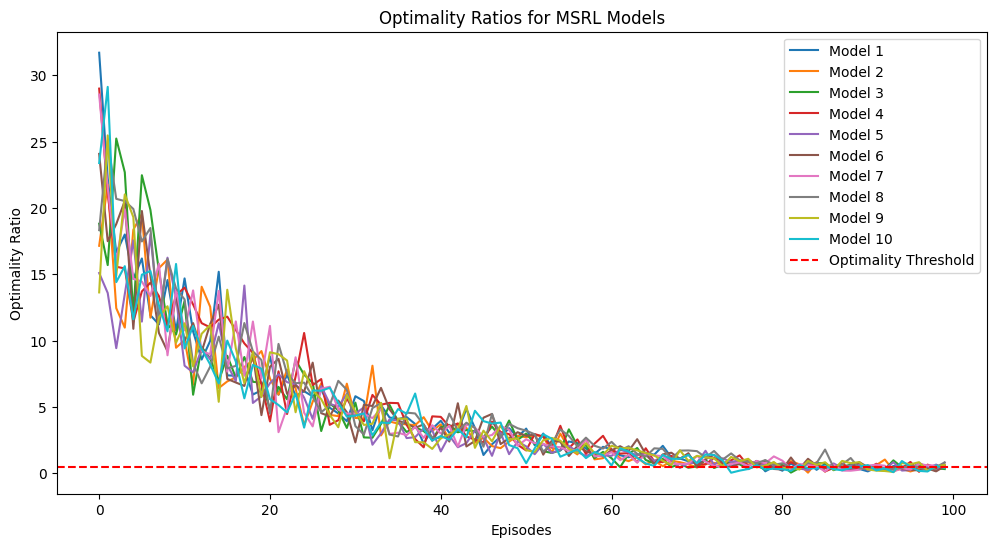

In [20]:
print('Maze: WM10')
plot_optimality_ratios_avg(experiment_data_no_pc_MW10, title='Optimality Ratios for Models Without Place Cells')
plot_optimality_ratios_avg(experiment_data_WM10_NM, title='Optimality Ratios for NM Models')
plot_optimality_ratios_avg(experiment_data_WM10_WM, title='Optimality Ratios for WM Models')
plot_optimality_ratios_avg(experiment_data_WM10_MSRL, title='Optimality Ratios for MSRL Models')